### normalizing inputs:

- Normalizing inputs in deep learning is a critical preprocessing step that scales feature values into a consistent range. This prevents features with larger magnitudes from dominating the learning process and ensures that the loss function's topology is better suited for optimization.

### Common Normalization Techniques Technique:

1. **Min-Max Scaling**:  ((x-x_{min})/(x_{max}-x_{min}))
- When you need a bounded range (e.g., [0, 1]) and data is not Gaussian.
- when data have outliers
- and we know the min and max values.


2. **Standardization (Z-score)**: ((x-mu )/sigma )
- When data follows a Gaussian distribution; it is less sensitive to outliers.
- and we don't know the min and max values.
- It scaled in range([-1,1])

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('D:\machine_learning\decision_trees\Social_Network_Ads.csv')

<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Durgesh Kumar\AppData\Local\Temp\ipykernel_8888\3441723679.py:1: SyntaxWarning: invalid escape sequence '\m'
  df = pd.read_csv('D:\machine_learning\decision_trees\Social_Network_Ads.csv')


In [3]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
df = df.iloc[:,2:]
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [5]:
import seaborn as sns

<Axes: xlabel='Age', ylabel='EstimatedSalary'>

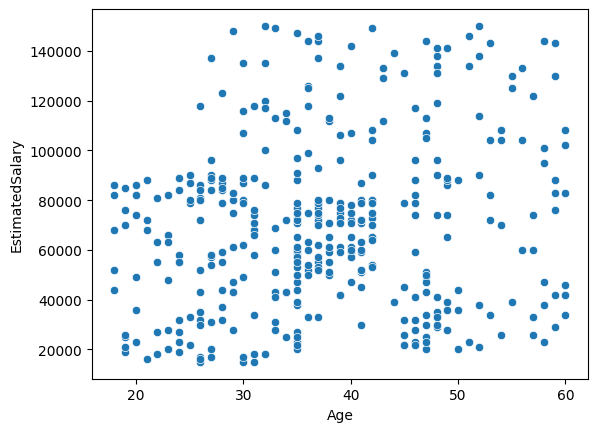

In [7]:
sns.scatterplot(x=df.iloc[:,0],y=df.iloc[:,1])

In [8]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from keras.layers import Dense

In [11]:
model = Sequential()
model.add(Dense(128,activation='relu',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

d:\anaconda3\envs\ml_1env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [16]:
history = model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=100)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5656 - loss: 255.9828 - val_accuracy: 0.4000 - val_loss: 88.3393
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4156 - loss: 88.0878 - val_accuracy: 0.6000 - val_loss: 101.5758
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5094 - loss: 100.6370 - val_accuracy: 0.6000 - val_loss: 202.8952
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5344 - loss: 137.9480 - val_accuracy: 0.6000 - val_loss: 286.4073
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4969 - loss: 214.0327 - val_accuracy: 0.4000 - val_loss: 61.2326
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5500 - loss: 119.0589 - val_accuracy: 0.4000 - val_loss: 58.4320
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5094 - loss: 88.1382 - val_accuracy: 0.6000 - val_loss: 68.5798
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5219 - loss: 102.7121 -

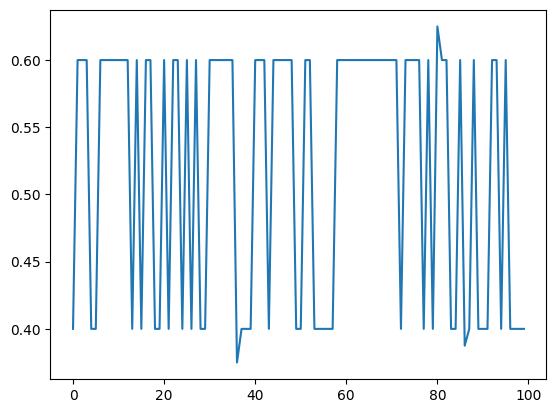

In [17]:
import matplotlib.pyplot as plt
plt.plot(history.history['val_accuracy'])

# Applying scaling

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<Axes: >

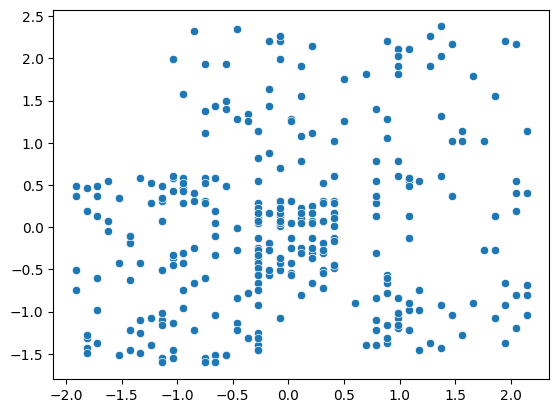

In [20]:
sns.scatterplot(x=X_train_scaled[:,0],y=X_train_scaled[:,1])

In [21]:
model = Sequential()

model.add(Dense(128,activation='relu',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

history = model.fit(X_train_scaled,y_train,validation_data=(X_test_scaled,y_test),epochs=100)

Epoch 1/100


d:\anaconda3\envs\ml_1env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.7719 - loss: 0.6405 - val_accuracy: 0.8000 - val_loss: 0.6107
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7812 - loss: 0.5989 - val_accuracy: 0.8000 - val_loss: 0.5664
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8062 - loss: 0.5614 - val_accuracy: 0.7875 - val_loss: 0.5267
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8188 - loss: 0.5271 - val_accuracy: 0.7875 - val_loss: 0.4921
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8344 - loss: 0.4945 - val_accuracy: 0.7875 - val_loss: 0.4609
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8375 - loss: 0.4658 - val_accuracy: 0.7875 - val_loss: 0.4327
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8500 - loss: 0.4397 - val_accuracy: 0.8000 - val_loss: 0.4072
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8625 - loss: 0.4143 - val_accuracy: 0.8375 - val_l

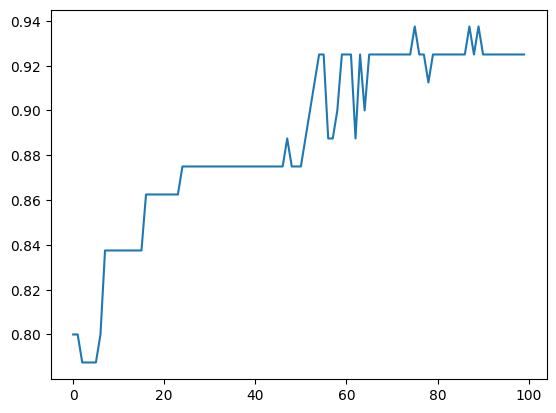

In [22]:
import matplotlib.pyplot as plt
plt.plot(history.history['val_accuracy'])